# Parametric maps

These map are quantification and measurement extracted from an image or labels and plotted back onto its corresponding labelled image for visual representation and further analysis.

In [1]:
import pyclesperanto as cle

from skimage.io import imread
from matplotlib import pyplot as plt
import numpy as np

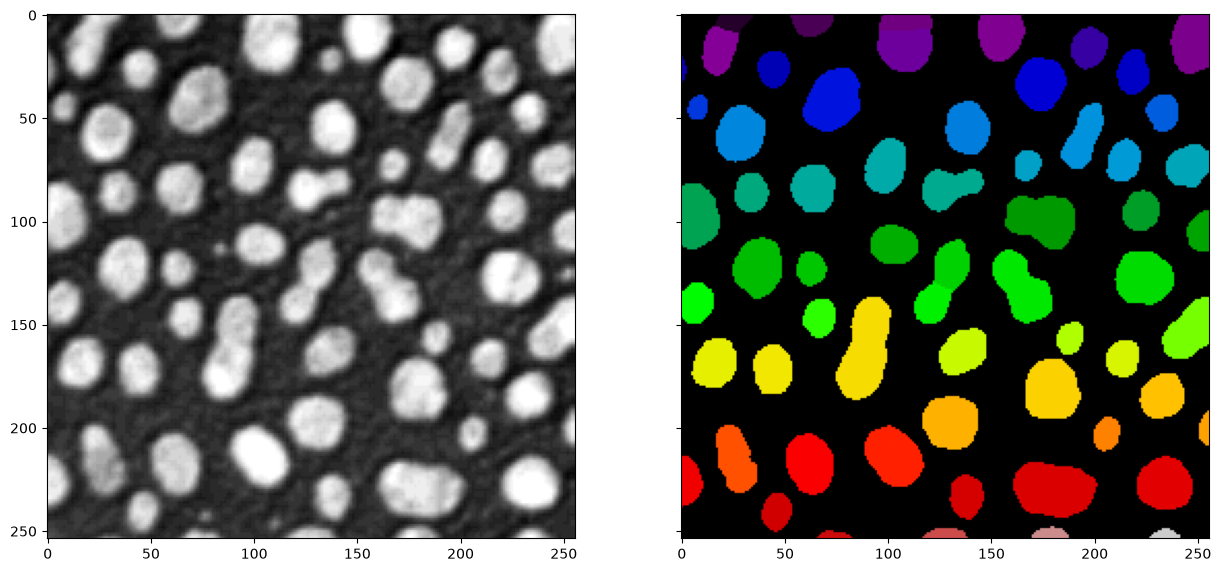

In [9]:
# load data
blobs = cle.push(imread('https://samples.fiji.sc/blobs.png').squeeze())
labels = cle.voronoi_otsu_labeling(blobs, spot_sigma=5, outline_sigma=1)

fig, axs = plt.subplots(1, 2, figsize=(15, 10), sharey=True)
axs[0].imshow(blobs, cmap="gray")
axs[1].imshow(labels, cmap="nipy_spectral")
plt.show()

# Quantitative maps a.k.a. parametric images

Once the objects are segmented in a label map, we can quantify these objects to extract various measurement (see [Region quantification](./regionprops_and_quantification.ipynb)). 
Parametric map are a way to plot these quantification onto the label map, for visualisation and further analysis.

To use `parametric_map` to plot values computed by `labels_statistics` and `labels_neighbors_statistics` function we need to compute them with `include_background` flage to `True`

In [10]:
props = cle.labels_statistics(labels, blobs, include_background=True)
nei_props = cle.labels_neighbors_statistics(labels, include_background=True)

Now we can the computed dictionary and labels to plot the value of our choice.

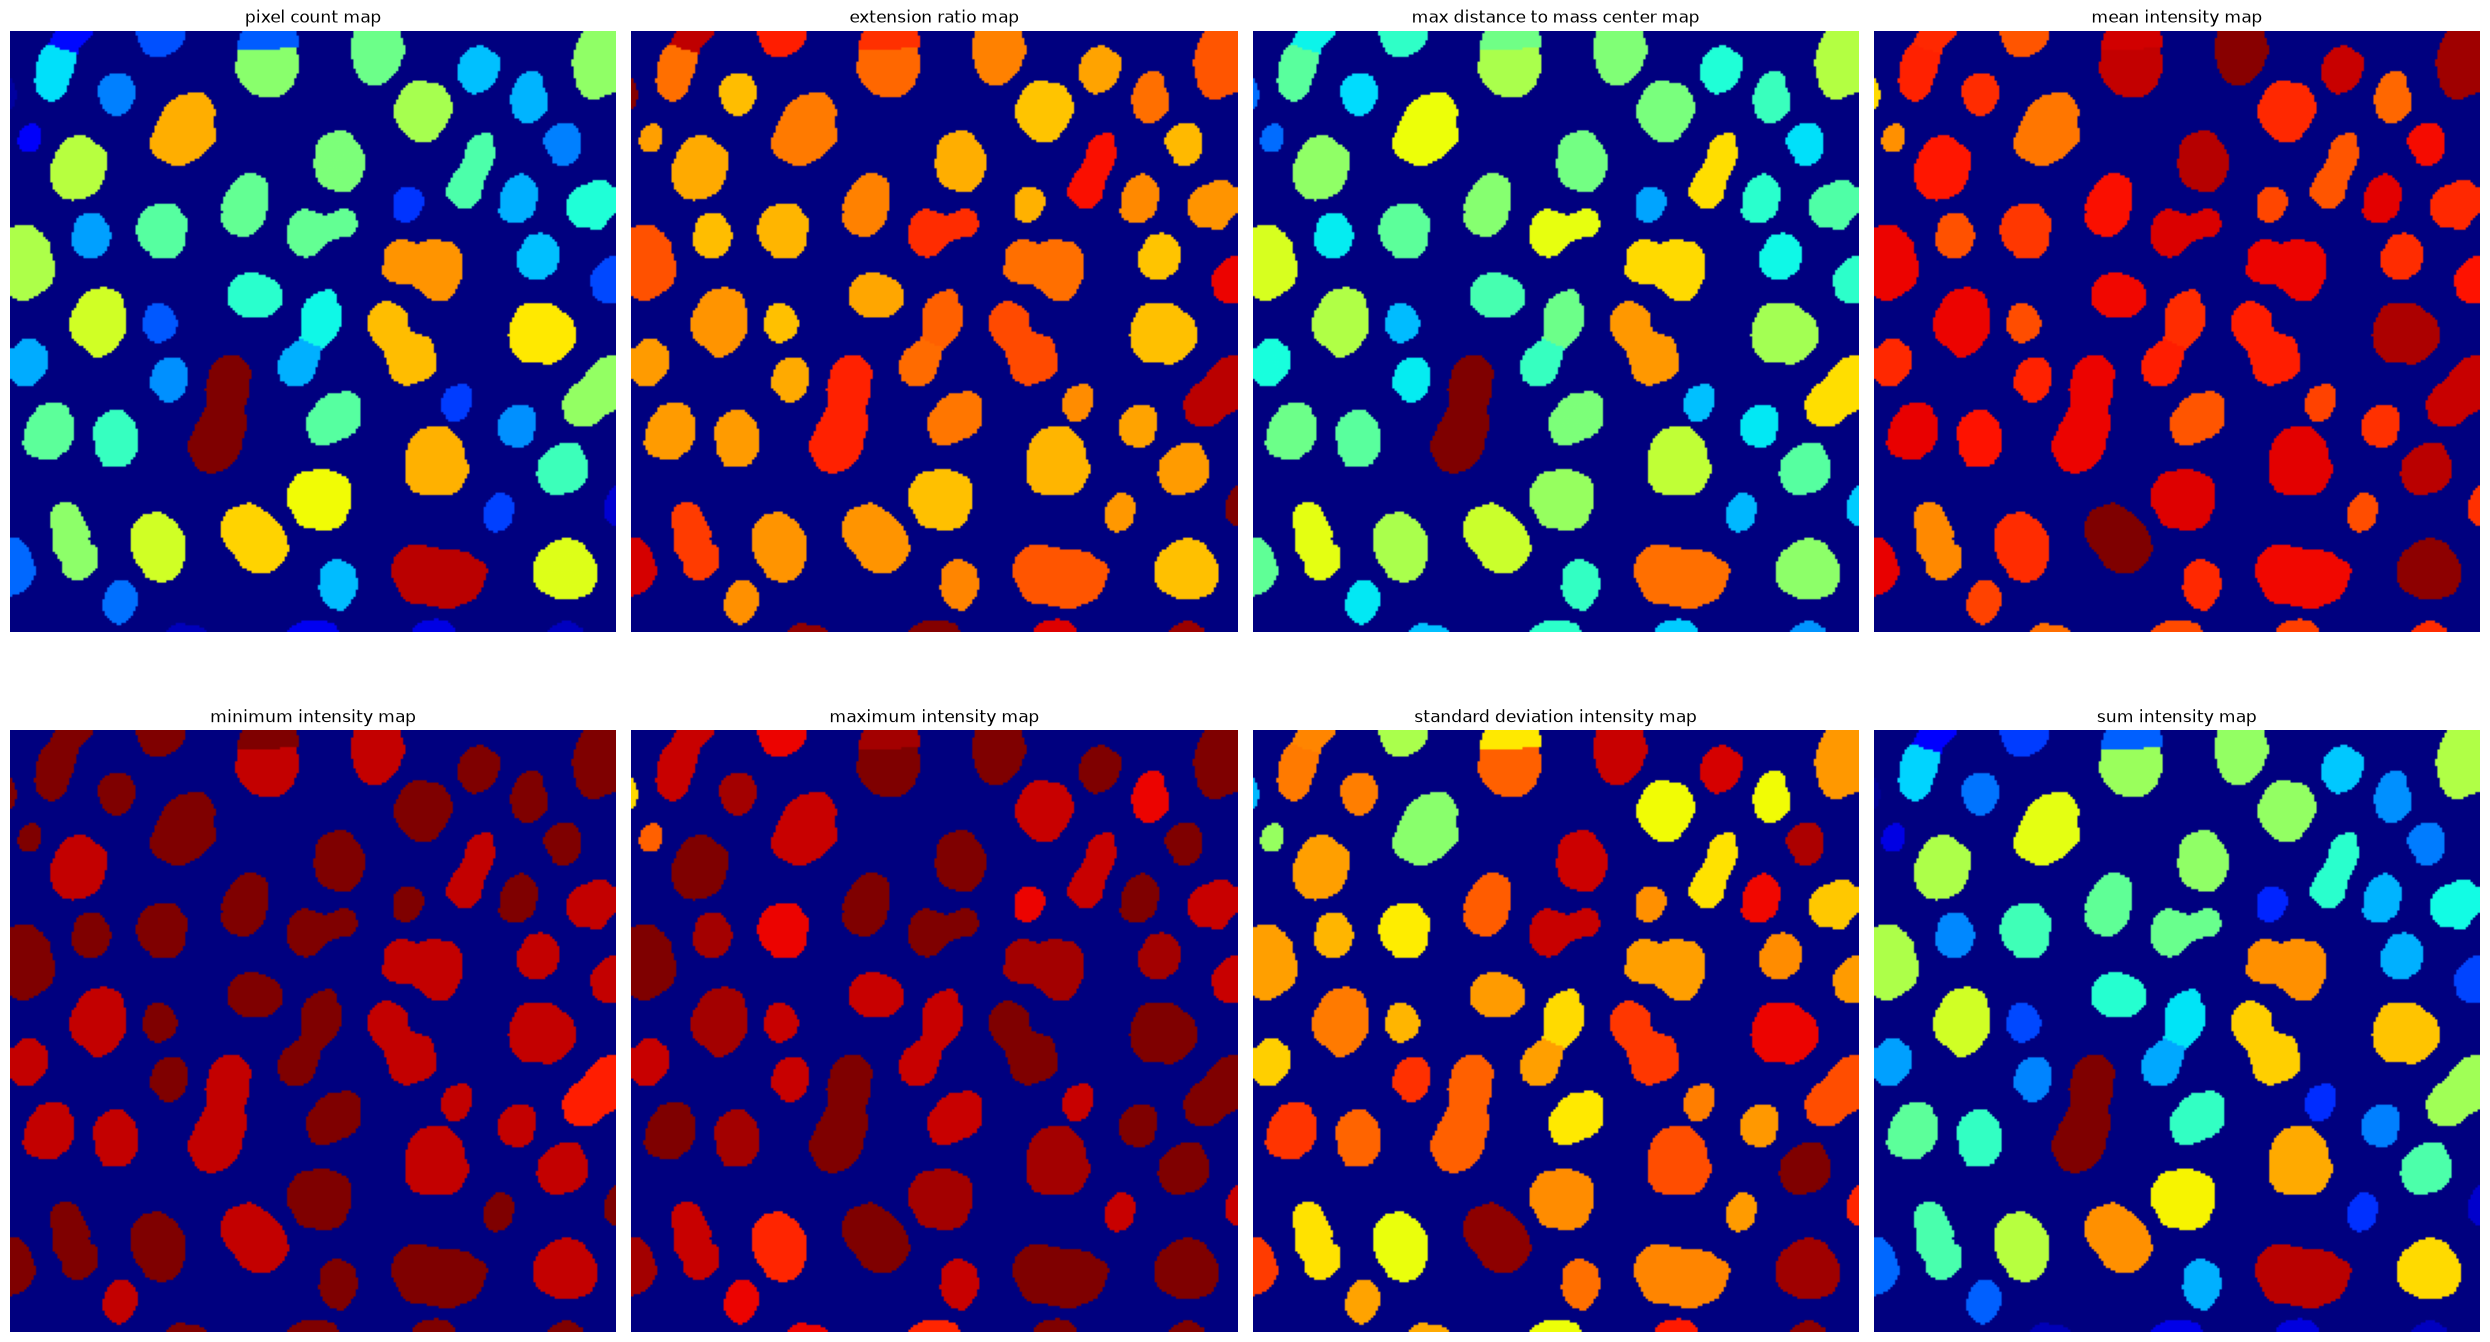

In [16]:
pixel_count_map = cle.parametric_map(labels, props, property="area")
extension_ratio_map = cle.parametric_map(labels, props, property="mean_max_distance_to_centroid_ratio")
max_distance_to_mass_center_map = cle.parametric_map(labels, props, property="max_distance_to_mass_center")
mean_intensity_map = cle.parametric_map(labels, props, property="mean_intensity")
minimum_intensity_map = cle.parametric_map(labels, props, property="min_intensity")
maximum_intensity_map = cle.parametric_map(labels, props, property="max_intensity")
stddev_intensity_map = cle.parametric_map(labels, props, property="standard_deviation_intensity")
sum_intensity_map = cle.parametric_map(labels, props, property="sum_intensity")

fig, axs = plt.subplots(2, 4, figsize=(25, 15))
axes = axs.ravel()
axes[0].imshow(pixel_count_map, cmap="jet")
axes[0].set_title("pixel count map")
axes[1].imshow(extension_ratio_map, cmap="jet")
axes[1].set_title("extension ratio map")
axes[2].imshow(max_distance_to_mass_center_map, cmap="jet")
axes[2].set_title("max distance to mass center map")
axes[3].imshow(mean_intensity_map, cmap="jet")
axes[3].set_title("mean intensity map")
axes[4].imshow(minimum_intensity_map, cmap="jet")
axes[4].set_title("minimum intensity map")
axes[5].imshow(maximum_intensity_map, cmap="jet")
axes[5].set_title("maximum intensity map")
axes[6].imshow(stddev_intensity_map, cmap="jet")
axes[6].set_title("standard deviation intensity map")
axes[7].imshow(sum_intensity_map, cmap="jet")
axes[7].set_title("sum intensity map")
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

We perform the same for neighborhood statistics

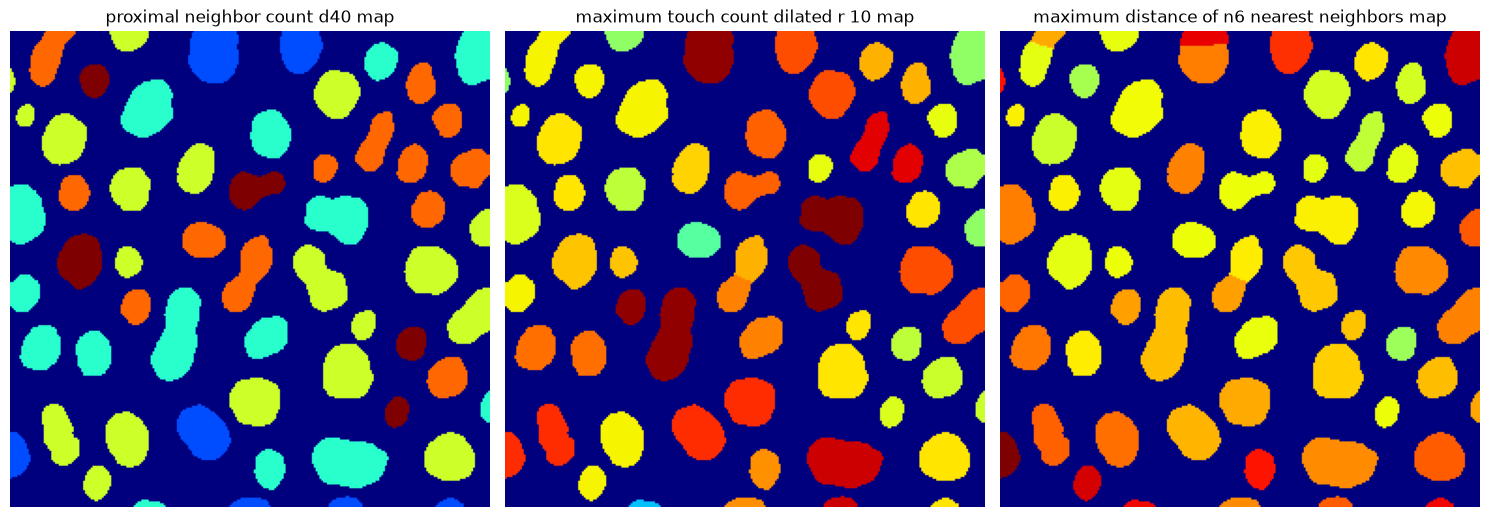

In [17]:
proximal_neighbor_count_d40_map = cle.parametric_map(labels, nei_props, property="proximal_neighbor_count_d40")
maximum_touch_count_dilated_r_10_map = cle.parametric_map(labels, nei_props, property="maximum_touch_count_dilated_r_10")
maximum_distance_of_n6_nearest_neighbors_map = cle.parametric_map(labels, nei_props, property="maximum_distance_of_n6_nearest_neighbors")
fig, axs = plt.subplots(1, 3, figsize=(15, 15))
axs[0].imshow(proximal_neighbor_count_d40_map, cmap="jet")
axs[0].set_title("proximal neighbor count d40 map")
axs[1].imshow(maximum_touch_count_dilated_r_10_map, cmap="jet")
axs[1].set_title("maximum touch count dilated r 10 map")
axs[2].imshow(maximum_distance_of_n6_nearest_neighbors_map, cmap="jet")
axs[2].set_title("maximum distance of n6 nearest neighbors map")
for ax in axs:
    ax.axis('off')
plt.tight_layout()
plt.show()